# Workshop 1 - Data Preprocessing and Supervised Learning


## Contexto y enfoque

Este trabajo se apoyará en los notebooks de referencia `MIAX ML - 01 Data Preprocessing.ipynb` y `MIAX ML - 03 Linear Regression.ipynb`.

El dataset base serán `navs.pickle` y los factores Fama-French que se descargaran mas adelante .
Se prioriza simplicidad, claridad y justificación explícita de cada decisión metodológica.

## 1. REESCRIBIR Objetivo y tesis financiera

Hipótesis financiera

Justificación económica y evidencia previa

Objetivo principal

> Nota: aunque una regresión de retorno futuro es viable, en este caso la clasificación es más alineada con la decisión real (supera/no supera benchmark).

Esto convierte el problema en clasificación binaria de “outperformers”.
Horizonte temporal de predicción

Restricciones y alcance de datos

Prevención de look-ahead 

Métricas candidatas y criterio de evaluación


## 2. Carga y alineación temporal de datos

Esta sección no busca todavía "mejorar" los datos, sino **hacerlos comparables en el tiempo** y dejar un punto de partida reproducible para el resto del pipeline.  
La decisión central es separar claramente tres capas:

1. **Estructura** (qué objetos y columnas tenemos),
2. **Tiempo** (cómo representamos fechas y cronología),
3. **Persistencia** (qué versión del dato guardamos para reutilizar).

El motivo es metodológico: si se mezclan decisiones de limpieza avanzada (fase 4) con alineación temporal (fase 2), se pierde trazabilidad y luego es más difícil justificar por qué una métrica cambió.

Además, en un problema financiero, la consistencia temporal es crítica: antes de modelar hay que garantizar que las series están en un marco común y que no hay artefactos de indexado/duplicación.

---

Qué hace concretamente esta sección

- **Carga** de `navs.pickle` (NAVs de fondos) y de factores Fama-French (Asia ex Japan 3 Factors + MOM), guardando copias locales en CSV para reproducibilidad.
- **Parseo y estandarización** de fechas en un formato común para todo el pipeline.
- **Orden cronológico** y eliminación de duplicados.


#### 2.1 Configuración y librerías

La configuración se centraliza al inicio (`PICKLE_PATH`), carpetas de salida,  para evitar “constantes ocultas” dentro de celdas posteriores.  
La razón práctica es doble:

- **Reproducibilidad**: cambiar una ruta o parámetro en un único sitio.
- **Auditabilidad**: dejar explícitas las decisiones de diseño antes de ejecutar transformaciones.

También se importan librerías de descarga y parseo robusto (`requests`, `zipfile`, `io`) porque se decidió evitar dependencias frágiles en la obtención de factores `panda_datareader`.


In [14]:
from pathlib import Path
import warnings
import os
import numpy as np
import pandas as pd
import pandas_datareader.data as web
from collections import Counter
import io
import zipfile
import requests
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# =========================
# Configuración
# =========================
PICKLE_PATH = Path("DOCS_CLASE") / "MachineLearning" / "dataset" / "navs.pickle"
OUTPUT_DIR = Path("data") / "daily_universe"
OUTPUT_PARQUET = OUTPUT_DIR / "panel_diario_universo.parquet"





#### 2.2 Carga y visualización inicial del `.pickle`

Aquí se valida primero la **estructura global del activo principal** (`navs_dict`) antes de transformar nada.  
La decisión de revisar `nº fondos`, `shape` agregado, columnas comunes y ejemplos concretos responde a una pregunta clave:  
**¿estamos tratando con un universo homogéneo o con múltiples excepciones estructurales?**

Se imprime una muestra de fondos para verificar que:
- el índice temporal existe,
- las columnas esperadas (`isin`, `allfunds_id`, `nav`, `name`) son consistentes,
- y el contenido es coherente con el contexto financiero.

Esto reduce riesgo de errores silenciosos en pasos posteriores (por ejemplo, asumir `date` como columna cuando viene en índice).

 Posibles críticas
- El `shape` agregado puede inducir falsa sensación de completitud (no refleja huecos temporales).
- Mostrar solo 3 fondos puede no capturar outliers estructurales.


In [15]:
# 1) Cargar archivo
navs_dict = pd.read_pickle(PICKLE_PATH)

# Validación básica
if not isinstance(navs_dict, dict):
    raise TypeError(f"Se esperaba un dict y se recibió: {type(navs_dict)}")

print("Archivo cargado correctamente")
print(f"Tipo de objeto: {type(navs_dict).__name__}")
print(f"Cantidad de fondos: {len(navs_dict):,}")

# 2) Métricas globales: filas totales, columnas comunes y shape global lógico
n_fondos = len(navs_dict)
total_filas = 0
common_cols = None
shapes = []
non_df_funds = 0

for fund_id, df in navs_dict.items():
    if not isinstance(df, pd.DataFrame):
        non_df_funds += 1
        continue

    shapes.append(df.shape)
    total_filas += df.shape[0]

    cols = set(df.columns)
    if common_cols is None:
        common_cols = cols
    else:
        common_cols = common_cols.intersection(cols)

common_cols = sorted(common_cols) if common_cols is not None else []
shape_global = (total_filas, len(common_cols))  # shape lógico agregado

print(f"Shape global (agregado lógico): {shape_global}")
print(f"Columnas comunes ({len(common_cols)}): {common_cols}")
if non_df_funds > 0:
    print(f"Advertencia: {non_df_funds} fondos no son DataFrame")

# 3) Distribución rápida de shapes (top 5)
shape_counts = Counter(shapes)
print("\nTop 5 shapes más frecuentes:")
for shp, cnt in shape_counts.most_common(5):
    print(f"  {shp}: {cnt} fondos")

# 4) Mostrar algunos ejemplos de fondos
sample_ids = list(navs_dict.keys())[:3]
print(f"\nEjemplo de fondos (primeros {len(sample_ids)}):")
for fid in sample_ids:
    obj = navs_dict[fid]
    print(f"\n--- Fondo {fid} ---")
    if isinstance(obj, pd.DataFrame):
        print(f"shape: {obj.shape}")
        print(f"columnas: {obj.columns.tolist()}")
        display(obj.head(5))
    else:
        print(f"No es DataFrame. Tipo: {type(obj)}")

Archivo cargado correctamente
Tipo de objeto: dict
Cantidad de fondos: 24,822
Shape global (agregado lógico): (29455509, 4)
Columnas comunes (4): ['allfunds_id', 'isin', 'name', 'nav']

Top 5 shapes más frecuentes:
  (1387, 4): 977 fondos
  (1383, 4): 819 fondos
  (1384, 4): 695 fondos
  (1385, 4): 689 fondos
  (1425, 4): 576 fondos

Ejemplo de fondos (primeros 3):

--- Fondo 90 ---
shape: (1387, 4)
columnas: ['isin', 'allfunds_id', 'nav', 'name']


,isin,allfunds_id,nav,name
date,,,,
2016-01-05,LU0171310443,90,16.47,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-06,LU0171310443,90,16.19,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-07,LU0171310443,90,15.68,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-08,LU0171310443,90,15.59,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-11,LU0171310443,90,15.26,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"



--- Fondo 541 ---
shape: (1373, 4)
columnas: ['isin', 'allfunds_id', 'nav', 'name']


,isin,allfunds_id,nav,name
date,,,,
2016-01-05,LU0248272758,541,27.54,"BGF INDIA ""A2"""
2016-01-06,LU0248272758,541,27.50,"BGF INDIA ""A2"""
2016-01-07,LU0248272758,541,26.83,"BGF INDIA ""A2"""
2016-01-08,LU0248272758,541,27.21,"BGF INDIA ""A2"""
2016-01-11,LU0248272758,541,26.98,"BGF INDIA ""A2"""



--- Fondo 909 ---
shape: (1299, 4)
columnas: ['isin', 'allfunds_id', 'nav', 'name']


,isin,allfunds_id,nav,name
date,,,,
2016-05-11,LU1408527916,909,10.00,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"
2016-05-12,LU1408527916,909,10.03,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"
2016-05-13,LU1408527916,909,10.06,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"
2016-05-17,LU1408527916,909,10.07,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"
2016-05-18,LU1408527916,909,10.07,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"


#### 2.3 Unificación diaria del universo en un único dataset

La decisión de transformar el diccionario de fondos en un **dataset largo diario** busca simplificar operaciones posteriores (merge temporal, controles de cobertura, joins con factores).  
Se convierte el índice a columna `date`, se estandarizan tipos y se resuelven duplicados por (`date`, `isin`) conservando la última observación, priorizando consistencia de clave temporal.

Se construye un panel diario completo `date x isin` para disponer de una matriz explícita de disponibilidad de NAV (observado vs faltante).  
Este enfoque favorece la transparencia de faltantes frente a enfoques donde los huecos quedan implícitos.

Guardar en `parquet` responde a una necesidad operativa: el CSV completo era muy pesado para trabajo y versionado.

Posibles críticas
- El producto cartesiano `date x isin` puede ser excesivo en memoria y disco.

Decisión de estructura: identificador único del fondo

Durante la construcción del dataset diario se detectó redundancia entre `fund_id` (clave del diccionario original) y `allfunds_id` (campo del propio dataset).  
En la práctica, ambas columnas representan el mismo identificador de fondo en las observaciones válidas.

Para reducir dimensionalidad y evitar duplicación semántica, se elimina `fund_id` y se conserva `allfunds_id` como identificador canónico, por ser el campo nativo del dato fuente y facilitar trazabilidad con el esquema original.

In [5]:
# Pipeline: navs_dict -> panel diario completo -> parquet
# Requiere navs_dict ya cargado en memoria

if "navs_dict" not in globals():
    raise ValueError("No existe `navs_dict` en memoria. Ejecuta primero la celda de carga.")

print("[1/6] Validando entrada...")
if not isinstance(navs_dict, dict):
    raise TypeError(f"`navs_dict` debe ser dict, recibido: {type(navs_dict)}")
print(f"    Fondos en diccionario: {len(navs_dict):,}")

print("[2/6] Aplanando a formato largo...")
rows = []

for fund_id, df in navs_dict.items():
    if not isinstance(df, pd.DataFrame):
        continue

    tmp = df.copy().reset_index()  # date está en índice
    tmp.columns = [str(c).strip().lower() for c in tmp.columns]

    # asegurar date
    if "date" not in tmp.columns:
        if "index" in tmp.columns:
            tmp = tmp.rename(columns={"index": "date"})
        else:
            tmp = tmp.rename(columns={tmp.columns[0]: "date"})

    # asegurar nav
    if "nav" not in tmp.columns:
        continue

    tmp["fund_id"] = fund_id
    # Evitamos duplicar IDs: conservamos allfunds_id como identificador canónico del fondo
    keep = ["date", "allfunds_id", "isin", "name", "nav"]
    keep = [c for c in keep if c in tmp.columns]
    tmp = tmp[keep]

    rows.append(tmp)

if not rows:
    raise RuntimeError("No se pudieron extraer fondos válidos con date/nav.")

daily_long_raw = pd.concat(rows, ignore_index=True)
print(f"    Filas concatenadas: {len(daily_long_raw):,}")

print("[3/6] Limpieza mínima de fecha y duplicados...")
daily_long_raw["date"] = pd.to_datetime(daily_long_raw["date"], errors="coerce", utc=True).dt.tz_localize(None)
daily_long_raw["nav"] = pd.to_numeric(daily_long_raw["nav"], errors="coerce")
daily_long_raw = daily_long_raw.dropna(subset=["date"]).copy()

if "isin" not in daily_long_raw.columns:
    raise RuntimeError("No existe columna 'isin'; no se puede construir panel por ISIN.")

daily_long_raw = (
    daily_long_raw
    .sort_values(["isin", "date"], kind="mergesort")
    .drop_duplicates(subset=["date", "isin"], keep="last")
    .reset_index(drop=True)
)

print("[4/6] Creando panel diario completo (date x isin)...")
global_min = daily_long_raw["date"].min()
global_max = daily_long_raw["date"].max()
all_days = pd.date_range(global_min, global_max, freq="D")
all_isins = daily_long_raw["isin"].dropna().drop_duplicates().sort_values()

calendar_df = pd.DataFrame({"date": all_days})
isins_df = pd.DataFrame({"isin": all_isins.values})
calendar_df["k"] = 1
isins_df["k"] = 1
daily_panel = calendar_df.merge(isins_df, on="k", how="inner").drop(columns="k")

obs = daily_long_raw[["date", "isin", "nav"]]
daily_panel = daily_panel.merge(obs, on=["date", "isin"], how="left")

meta_cols = [c for c in ["allfunds_id", "name"] if c in daily_long_raw.columns]
if meta_cols:
    meta_by_isin = (
        daily_long_raw
        .sort_values(["isin", "date"])
        .drop_duplicates(subset=["isin"], keep="last")[["isin"] + meta_cols]
    )
    daily_panel = daily_panel.merge(meta_by_isin, on="isin", how="left")

daily_panel = daily_panel.sort_values(["date", "isin"]).reset_index(drop=True)

print(f"    Rango global: {global_min.date()} -> {global_max.date()}")
print(f"    Filas panel: {len(daily_panel):,}")

print("[5/6] Guardando parquet...")
OUT_DIR = Path("data") / "daily_universe"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PARQUET = OUT_DIR / "panel_diario_universo.parquet"
if OUT_PARQUET.exists():
    OUT_PARQUET.unlink()

daily_panel.to_parquet(OUT_PARQUET, index=False)

print(f"    Parquet guardado en: {OUT_PARQUET.as_posix()}")

print("[6/6] Vista previa")
display(daily_panel.head(10))

[1/6] Validando entrada...
    Fondos en diccionario: 24,822
[2/6] Aplanando a formato largo...
    Filas concatenadas: 29,455,509
[3/6] Limpieza mínima de fecha y duplicados...
[4/6] Creando panel diario completo (date x isin)...
    Rango global: 2016-01-05 -> 2021-07-16
    Filas panel: 50,134,380
[5/6] Guardando parquet...
    Parquet guardado en: data/daily_universe/panel_diario_universo.parquet
[6/6] Vista previa


,date,isin,nav,allfunds_id,name
0,2016-01-05,AT0000494893,297.13,60265,"ERSTE STOCK ISTANBUL ""VT"" (EUR)"
1,2016-01-05,AT0000495304,142.24,21156,"RAIFFEISEN TOP DIVIDEND EQ ""R-VTA"" ACC"
2,2016-01-05,AT0000497268,215.88,21157,"RAIFFEISEN EMERGING M ""R"" (EUR) A"
3,2016-01-05,AT0000607270,177.58,817028,"RAIFFEISEN 304 EURO COR ""I-VTA"" ACC"
4,2016-01-05,AT0000673165,484.11,60256,"ERSTE STOCK BIOTEC ""VTA"" (EUR)"
5,2016-01-05,AT0000673181,74.41,60271,"ERSTE STOCK EUROPE EMERGING ""VT"" (EUR)"
6,2016-01-05,AT0000673199,172.47,60268,"ERSTE BOND DANUBIA ""VT"" EUR"
7,2016-01-05,AT0000673306,181.43,173258,"ERSTE BOND EM GOVERNMENT ""VT"" (EUR)"
8,2016-01-05,AT0000704333,234.64,60264,"ERSTE STOCK ISTANBUL ""A"" (EUR) D"
9,2016-01-05,AT0000712534,190.69,817008,"RAIFFEISEN EURO CORPO ""R"" (EUR) A"


#### 2.4 Carga de factores Fama-French (Asia ex Japan)

Se decide descargar factores directamente desde los ZIP oficiales de Ken French en lugar de depender de `pandas_datareader`. El motivo principal es de **robustez y mantenimiento**: evitar warnings deprecados internos y reducir dependencia de implementaciones intermedias que pueden cambiar.

La normalización posterior (`date` a `datetime`, orden, deduplicación, conversión numérica) busca dejar factores listos para cruce temporal con NAVs sin ambigüedades de parseo.

Guardar una copia local en `data/factors` responde a reproducibilidad: una vez descargado, el pipeline no depende de red en cada ejecución.


In [ ]:
# =========================================================
# Descarga directa desde Ken French (ZIP) + guardado en CSV
# =========================================================

print("[1/7] Configurando carpeta de salida...")
FACTORS_DIR = Path("data") / "factors"
FACTORS_DIR.mkdir(parents=True, exist_ok=True)
print(f"    Carpeta: {FACTORS_DIR.as_posix()}")

print("[2/7] Definiendo función de descarga/parseo robusta...")

def load_ken_french_daily_zip(url: str) -> pd.DataFrame:
    # Descargar ZIP
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()

    # Leer archivo interno txt/csv
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        inner_files = [n for n in zf.namelist() if n.lower().endswith((".txt", ".csv"))]
        if not inner_files:
            raise RuntimeError(f"No se encontró TXT/CSV dentro del ZIP: {url}")
        inner_name = inner_files[0]
        lines = zf.read(inner_name).decode("latin1", errors="ignore").splitlines()

    # Buscar inicio de tabla diaria: primera línea con fecha YYYYMMDD
    start_data = None
    for i, line in enumerate(lines):
        s = line.strip()
        if len(s) >= 8 and s[:8].isdigit():
            # normalmente el header está justo arriba
            start_data = max(i - 1, 0)
            break
    if start_data is None:
        raise RuntimeError(f"No se encontró bloque de datos en: {url}")

    # Cortar bloque útil (hasta notas/metadatos del final)
    block = []
    for line in lines[start_data:]:
        s = line.strip()
        if s == "":
            # después de arrancar y tener varias líneas, vacío suele marcar fin de bloque
            if len(block) > 5:
                break
            continue
        block.append(line)

    if len(block) < 2:
        raise RuntimeError(f"Bloque de datos insuficiente en: {url}")

    # Parsear tabla
    df = pd.read_csv(io.StringIO("\n".join(block)))

    # Normalizar columna fecha
    first_col = df.columns[0]
    df = df.rename(columns={first_col: "date"})
    df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")

    # Limpieza mínima estructural
    df = (
        df.dropna(subset=["date"])
          .sort_values("date")
          .drop_duplicates(subset=["date"], keep="last")
          .reset_index(drop=True)
    )

    # Convertir factores a numérico
    for c in df.columns:
        if c != "date":
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


print("[3/7] Descargando factores Asia ex Japan desde Ken French...")
URL_3F = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Asia_Pacific_ex_Japan_3_Factors_Daily_CSV.zip"
URL_MOM = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Asia_Pacific_ex_Japan_MOM_Factor_Daily_CSV.zip"

ff_asia = load_ken_french_daily_zip(URL_3F)
mom_asia = load_ken_french_daily_zip(URL_MOM)

print("[4/7] Control de estructura descargada...")
print(f"    FF filas: {len(ff_asia):,} | columnas: {ff_asia.columns.tolist()}")
print(f"    MOM filas: {len(mom_asia):,} | columnas: {mom_asia.columns.tolist()}")
print(f"    FF rango: {ff_asia['date'].min().date()} -> {ff_asia['date'].max().date()}")
print(f"    MOM rango: {mom_asia['date'].min().date()} -> {mom_asia['date'].max().date()}")

print("[5/7] Guardando CSV locales (reemplazo si existen)...")
FF_CSV = FACTORS_DIR / "ff_asia_pacific_3factors_daily.csv"
MOM_CSV = FACTORS_DIR / "mom_asia_pacific_daily.csv"

if FF_CSV.exists():
    FF_CSV.unlink()
if MOM_CSV.exists():
    MOM_CSV.unlink()

ff_asia.to_csv(FF_CSV, index=False, encoding="utf-8")
mom_asia.to_csv(MOM_CSV, index=False, encoding="utf-8")

print(f"    Guardado: {FF_CSV.as_posix()}")
print(f"    Guardado: {MOM_CSV.as_posix()}")

print("[6/7] Preview")
display(ff_asia.head(5))
display(mom_asia.head(5))

print("[7/7] Factores listos para cruce temporal con NAVs.")

[1/7] Configurando carpeta de salida...
    Carpeta: data/factors
[2/7] Definiendo función de descarga/parseo robusta...
[3/7] Descargando factores Asia ex Japan desde Ken French...
[4/7] Control de estructura descargada...
    FF filas: 9,285 | columnas: ['date', 'Mkt-RF', 'SMB', 'HML', 'RF']
    MOM filas: 9,197 | columnas: ['date', 'WML']
    FF rango: 1990-07-02 -> 2026-01-30
    MOM rango: 1990-11-01 -> 2026-01-30
[5/7] Guardando CSV locales (reemplazo si existen)...
    Guardado: data/factors/ff_asia_pacific_3factors_daily.csv
    Guardado: data/factors/mom_asia_pacific_daily.csv
[6/7] Preview


,date,Mkt-RF,SMB,HML,RF
0,1990-07-02,0.40,-0.09,0.60,0.03
1,1990-07-03,0.86,-0.64,0.30,0.03
2,1990-07-04,1.28,-0.29,-0.30,0.03
3,1990-07-05,0.20,-0.57,-0.34,0.03
4,1990-07-06,-0.07,-0.16,0.42,0.03


,date,WML
0,1990-11-01,0.72
1,1990-11-02,0.96
2,1990-11-05,-1.41
3,1990-11-06,-0.13
4,1990-11-07,0.01


[7/7] Factores listos para cruce temporal con NAVs.


#### 2.5 Unificación de factores en un único dataset

Unificar `Mkt-RF`, `SMB`, `HML`, `RF` con `WML` en una sola tabla reduce complejidad en etapas de modelado y evita joins repetidos.  
La decisión de usar `inner join` por `date` es deliberada: solo se conservan fechas donde todos los factores relevantes existen, garantizando una base consistente para features.

Esto implica que el inicio temporal queda determinado por el factor con menor historial (`WML`), lo cual en este caso es aceptable porque no se requiere explotar periodos anteriores para el análisis actual, podria recortarse incluso hasta la fecha de inicio del archivo navs.pickle.

El resultado (`factores_unificados.csv`) actúa como fuente canónica de factores para el resto del notebook.


In [8]:
#Unificación de factores (3 factores + momentum WML)

print("[1/6] Cargando CSV de factores...")
FACTORS_DIR = Path("data") / "factors"
ff_path = FACTORS_DIR / "ff_asia_pacific_3factors_daily.csv"
mom_path = FACTORS_DIR / "mom_asia_pacific_daily.csv"

ff = pd.read_csv(ff_path)
mom = pd.read_csv(mom_path)

print(f"    FF shape : {ff.shape}")
print(f"    MOM shape: {mom.shape}")

print("[2/6] Normalizando fechas y tipos...")
ff["date"] = pd.to_datetime(ff["date"], errors="coerce")
mom["date"] = pd.to_datetime(mom["date"], errors="coerce")

ff = ff.dropna(subset=["date"]).copy()
mom = mom.dropna(subset=["date"]).copy()

# Asegurar numérico en factores
for c in ["Mkt-RF", "SMB", "HML", "RF"]:
    if c in ff.columns:
        ff[c] = pd.to_numeric(ff[c], errors="coerce")

if "WML" in mom.columns:
    mom["WML"] = pd.to_numeric(mom["WML"], errors="coerce")
else:
    raise RuntimeError("No se encontró la columna 'WML' en mom_asia_pacific_daily.csv")

print("[3/6] Ordenando y quitando duplicados por fecha...")
ff = ff.sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)
mom = mom.sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)

print("[4/6] Uniendo datasets por fecha...")
# inner join => solo fechas comunes (arranca cuando existe WML)
factores_unificados = ff.merge(mom[["date", "WML"]], on="date", how="inner")
factores_unificados = factores_unificados.sort_values("date").reset_index(drop=True)

print("[5/6] Control de resultado...")
print(f"    Shape unificado: {factores_unificados.shape}")
print(f"    Columnas: {factores_unificados.columns.tolist()}")
print(f"    Rango: {factores_unificados['date'].min().date()} -> {factores_unificados['date'].max().date()}")

print("[6/6] Guardando CSV final...")
out_path = FACTORS_DIR / "factores_unificados.csv"
if out_path.exists():
    out_path.unlink()

factores_unificados.to_csv(out_path, index=False, encoding="utf-8")
print(f"    Guardado en: {out_path.as_posix()}")

display(factores_unificados.head(10))

[1/6] Cargando CSV de factores...
    FF shape : (9285, 5)
    MOM shape: (9197, 2)
[2/6] Normalizando fechas y tipos...
[3/6] Ordenando y quitando duplicados por fecha...
[4/6] Uniendo datasets por fecha...
[5/6] Control de resultado...
    Shape unificado: (9197, 6)
    Columnas: ['date', 'Mkt-RF', 'SMB', 'HML', 'RF', 'WML']
    Rango: 1990-11-01 -> 2026-01-30
[6/6] Guardando CSV final...
    Guardado en: data/factors/factores_unificados.csv


,date,Mkt-RF,SMB,HML,RF,WML
0,1990-11-01,-1.38,0.97,0.07,0.03,0.72
1,1990-11-02,-1.03,-0.05,-0.26,0.03,0.96
2,1990-11-05,1.20,-0.67,0.26,0.03,-1.41
3,1990-11-06,0.40,0.01,-0.30,0.03,-0.13
4,1990-11-07,-0.22,-0.51,-0.43,0.03,0.01
5,1990-11-08,-0.14,-0.32,1.05,0.03,0.03
6,1990-11-09,-0.56,0.70,-0.15,0.03,0.67
7,1990-11-12,0.44,-0.52,0.00,0.03,0.60
8,1990-11-13,0.87,-1.32,-0.19,0.03,0.42
9,1990-11-14,-0.29,-0.46,0.46,0.03,1.19


## 3. EDA (exploración de calidad)

En esta sección se revisa la calidad de los datos de forma **solo diagnóstica**: tamaños, tipos, nulos y comportamientos básicos. El objetivo es detectar problemas antes de limpiar y modelar, sin aplicar correcciones ni imputaciones.

Se trabaja sobre `daily_panel` (y factores cuando proceda) y se cubre:
- **Vista general** (3.1): shape, tipos, nulos globales, consistencia de metadatos.
- **Cobertura temporal** (3.2): completitud por fondo, heterogeneidad de historial.
- **Frecuencia de actualización** (3.3): distinción entre NaN por frecuencia natural vs. falta de datos.
- **Calidad de NAV** (3.4): valores no plausibles (≤0), saltos extremos, anomalías preliminares.
- **Sistema de alertas** (3.5): umbrales por fondo para priorizar la fase de limpieza.

---

**Decisiones a justificar (y cómo se justifican en este notebook)**

| Decisión | Valor adoptado | Justificación |
|----------|----------------|---------------|
| **Indicadores de calidad prioritarios** | Shape, tipos, nulos globales; cobertura por fondo (ratio_completitud, obs_nav_no_nulo); frecuencia observada; calidad de NAV (≤0, extremos); flags consolidados | Se priorizan porque definen qué fondos son aptos para modelado y qué problemas hay que resolver antes. La cobertura por fondo evita mezclar fondos con historial suficiente con otros casi vacíos. La frecuencia distingue NaN estructural (semanal/mensual) de mala calidad. |
| **Gráficos mínimos** | Barras de nulos por columna (3.1); barras de distribución de frecuencia (3.3); histogramas y umbrales de extremos para retornos (3.4); tablas Top 50 menor/mayor cobertura (3.2) | Las barras de nulos detectan columnas problemáticas de forma rápida. La distribución de frecuencia explica gran parte de los NaN. Los histogramas de retornos revelan outliers. Las tablas de cobertura orientan el filtrado en la fase 4. |
| **Umbrales preliminares para alertas** | `cobertura_baja < 0.60`; `historial < 252` obs; `nav_null_alto > 0.50` | **0.60**: ratio de completitud bajo indica muchos huecos; umbral estándar conservador. **252**: ~1 año de días laborables; mínimo razonable para series temporales. **0.50**: más de la mitad de NAV nulos implica señal muy incompleta. Estos umbrales son **preliminares** y se revisan en la fase 4. |

---

**Entregable de la sección:** resumen de calidad con tablas y gráficos básicos de diagnóstico, y sistema de alertas que sirva de puente a la fase 4.

### 3.1 - Vista general de calidad del dataset

Diagnóstico inicial de calidad sobre `daily_panel` para validar estructura, cobertura e integridad antes de la fase de limpieza.

**Qué hace esta subsección:**
- Shape (filas × columnas) y número de fondos por `allfunds_id` e `isin`.
- Rango temporal global (fecha mínima y máxima).
- Porcentaje global de `nav` nulo. 
- Listado de columnas disponibles.
- Controles de consistencia de metadatos: ausencia de múltiples ISIN por `allfunds_id`, múltiples IDs por ISIN, múltiples nombres por identificador.
- Gráfico de barras de % de nulos en variables clave (`nav`, `allfunds_id`, `isin`, `name`, `date`).

**Posibles críticas**
- El % global de nulos puede ser engañoso en panel diario (muchos NaN son estructurales por frecuencia de publicación).
- La consistencia de metadatos no detecta errores más sutiles (p. ej. cambios de nombre en el tiempo).

SECCION 3.1 - VISTA GENERAL DE CALIDAD (DIAGNOSTICO INICIAL)
Shape: 50,134,380 filas x 5 columnas
N fondos por allfunds_id: 24819
N fondos por isin: 24819
Rango temporal global (date): 2016-01-05 00:00:00 -> 2021-07-16 00:00:00
% global de nav nulo: 41.25%
----------------------------------------------------------------------------------------
Columnas disponibles:
['date', 'isin', 'nav', 'allfunds_id', 'name']
----------------------------------------------------------------------------------------
Consistencia basica de metadatos:
  - allfunds_id_con_multiples_isin: 0
  - isin_con_multiples_allfunds_id: 0
  - allfunds_id_con_multiples_name: 0
  - isin_con_multiples_name: 0


,metrica,valor
0,n_filas,50134380
1,n_columnas,5
2,n_fondos_por_allfunds_id,24819
3,n_fondos_por_isin,24819
4,fecha_min_global,2016-01-05 00:00:00
5,fecha_max_global,2021-07-16 00:00:00
6,porcentaje_nav_nulo,41.247471
7,allfunds_id_con_multiples_isin,0
8,isin_con_multiples_allfunds_id,0
9,allfunds_id_con_multiples_name,0


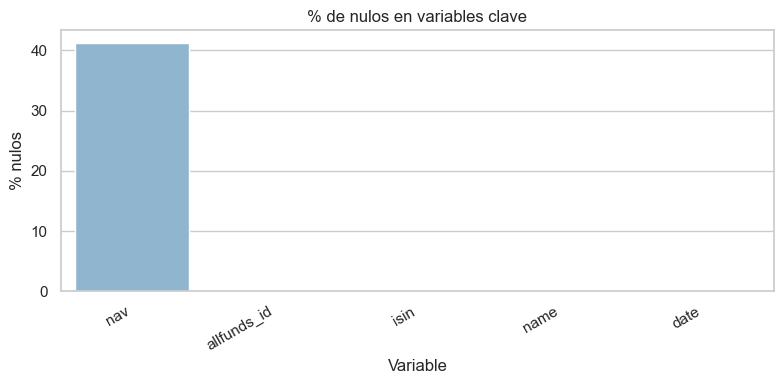

In [ ]:
# Diagnóstico inicial: sin limpieza correctiva ni transformación de frecuencia.


if "daily_panel" not in globals():
    raise NameError(
        "No existe `daily_panel` en memoria. Ejecuta antes la fase de construccion/carga del panel diario."
    )

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

# Referencia directa para evitar copiar un dataset potencialmente grande.
df = daily_panel


def detect_date_col(dataframe: pd.DataFrame):
    preferred = ["date", "nav_date", "fecha", "datetime", "timestamp"]
    cols_lower = {c.lower(): c for c in dataframe.columns}

    for candidate in preferred:
        if candidate in cols_lower:
            return cols_lower[candidate]

    dt_cols = dataframe.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    return dt_cols[0] if dt_cols else None


def safe_nunique(dataframe: pd.DataFrame, col: str):
    if col not in dataframe.columns:
        return np.nan
    return dataframe[col].nunique(dropna=True)


# 1) Shape y columnas
n_rows, n_cols = df.shape
column_list = df.columns.tolist()

# 2) Numero de fondos
n_funds_allfunds = safe_nunique(df, "allfunds_id")
n_funds_isin = safe_nunique(df, "isin")

# 3) Rango temporal global
date_col = detect_date_col(df)
if date_col is not None:
    date_series = pd.to_datetime(df[date_col], errors="coerce")
    date_min = date_series.min()
    date_max = date_series.max()
else:
    date_min, date_max = pd.NaT, pd.NaT

# 4) NAV nulo global
nav_null_pct = (df["nav"].isna().mean() * 100) if "nav" in df.columns else np.nan

# 5) Consistencia basica de metadatos
issues = {
    "allfunds_id_con_multiples_isin": np.nan,
    "isin_con_multiples_allfunds_id": np.nan,
    "allfunds_id_con_multiples_name": np.nan,
    "isin_con_multiples_name": np.nan,
}

if {"allfunds_id", "isin"}.issubset(df.columns):
    id_to_isin = df.dropna(subset=["allfunds_id"]).groupby("allfunds_id")["isin"].nunique(dropna=True)
    isin_to_id = df.dropna(subset=["isin"]).groupby("isin")["allfunds_id"].nunique(dropna=True)
    issues["allfunds_id_con_multiples_isin"] = int((id_to_isin > 1).sum())
    issues["isin_con_multiples_allfunds_id"] = int((isin_to_id > 1).sum())

if {"allfunds_id", "name"}.issubset(df.columns):
    id_to_name = df.dropna(subset=["allfunds_id"]).groupby("allfunds_id")["name"].nunique(dropna=True)
    issues["allfunds_id_con_multiples_name"] = int((id_to_name > 1).sum())

if {"isin", "name"}.issubset(df.columns):
    isin_to_name = df.dropna(subset=["isin"]).groupby("isin")["name"].nunique(dropna=True)
    issues["isin_con_multiples_name"] = int((isin_to_name > 1).sum())

# 6) Tabla resumen para reporte
summary_31 = pd.DataFrame(
    {
        "metrica": [
            "n_filas",
            "n_columnas",
            "n_fondos_por_allfunds_id",
            "n_fondos_por_isin",
            "fecha_min_global",
            "fecha_max_global",
            "porcentaje_nav_nulo",
            "allfunds_id_con_multiples_isin",
            "isin_con_multiples_allfunds_id",
            "allfunds_id_con_multiples_name",
            "isin_con_multiples_name",
        ],
        "valor": [
            n_rows,
            n_cols,
            n_funds_allfunds,
            n_funds_isin,
            date_min,
            date_max,
            nav_null_pct,
            issues["allfunds_id_con_multiples_isin"],
            issues["isin_con_multiples_allfunds_id"],
            issues["allfunds_id_con_multiples_name"],
            issues["isin_con_multiples_name"],
        ],
    }
)

print("=" * 88)
print("SECCION 3.1 - VISTA GENERAL DE CALIDAD (DIAGNOSTICO INICIAL)")
print("=" * 88)
print(f"Shape: {n_rows:,} filas x {n_cols:,} columnas")
print(f"N fondos por allfunds_id: {n_funds_allfunds if not pd.isna(n_funds_allfunds) else 'N/A'}")
print(f"N fondos por isin: {n_funds_isin if not pd.isna(n_funds_isin) else 'N/A'}")
print(f"Rango temporal global ({date_col if date_col else 'sin columna fecha'}): {date_min} -> {date_max}")
if pd.isna(nav_null_pct):
    print("% global de nav nulo: N/A (columna 'nav' no disponible)")
else:
    print(f"% global de nav nulo: {nav_null_pct:.2f}%")
print("-" * 88)
print("Columnas disponibles:")
print(column_list)
print("-" * 88)
print("Consistencia basica de metadatos:")
for k, v in issues.items():
    print(f"  - {k}: {v}")
print("=" * 88)

display(summary_31)

# Visual simple de nulos en columnas clave
key_cols = [c for c in ["nav", "allfunds_id", "isin", "name", date_col] if c is not None and c in df.columns]
if key_cols:
    nulls_key = (df[key_cols].isna().mean() * 100).sort_values(ascending=False)

    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=nulls_key.index, y=nulls_key.values, hue=nulls_key.index, palette="Blues_d", legend=False)
    ax.set_title("% de nulos en variables clave")
    ax.set_xlabel("Variable")
    ax.set_ylabel("% nulos")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No hay columnas clave disponibles para graficar nulos.")

Interpretación de consistencia básica de metadatos (3.1)

| Métrica | Significado | Si = 0 |
|---------|-------------|--------|
| `allfunds_id_con_multiples_isin` | Fondos que tienen más de un ISIN asociado | Cada fondo tiene un solo ISIN |
| `isin_con_multiples_allfunds_id` | ISIN que apuntan a más de un fondo | Cada ISIN corresponde a un solo fondo |
| `allfunds_id_con_multiples_name` | Fondos con más de un nombre distinto | Cada fondo tiene un solo nombre |
| `isin_con_multiples_name` | ISIN con más de un nombre | Cada ISIN tiene un solo nombre |

**Decisiones que permite:**

- `allfunds_id` e `isin` son claves válidas para joins y agrupaciones.
- No hay ambigüedad entre identificadores.
- Se puede usar cualquier identificador como clave principal para metadatos.
- En la fase 4 se puede agrupar por fondo sin riesgo de mezclar registros distintos.


### 3.2 - Cobertura temporal y completitud por fondo

En datasets financieros de panel, mirar solo métricas globales puede ocultar un riesgo clave: **heterogeneidad de historial entre fondos**. Dos fondos pueden convivir en el mismo dataset, pero uno tener una serie casi completa y otro estar severamente incompleto.

Por eso, en esta subsección diagnosticamos cobertura **a nivel fondo** (clave real para modelado), midiendo:

- `min_date` y `max_date` para delimitar ventana observada por fondo.
- observaciones con `nav` no nulo para cuantificar señal utilizable.
- días calendario entre `min_date` y `max_date` para estimar densidad temporal.
- ratio de completitud (`obs_no_nulo / dias_calendario`) para comparar fondos en escala homogénea.
- flag de mínimo historial de 1 año (>= 252 observaciones con NAV) como criterio preliminar de elegibilidad.

Por qué al menos 1 año de historial

| Razón | Explicación |
|-------|-------------|
| **Estimación de retornos** | Con muy pocas observaciones, los retornos calculados son muy ruidosos. Un año da suficiente serie para estimar volatilidad y tendencia con más estabilidad. |
| **Features y ventanas temporales** | Medias móviles, volatilidad reciente u otros indicadores suelen usar ventanas de varias semanas o meses. Con menos de 1 año no tienes margen razonable para calcular esas features. |
| **Cobertura de estacionalidad** | Un año cubre ciclos estacionales (trimestres, semestres). Fondos con menos de 1 año no permiten evaluar un comportamiento medio/largo plazo. |
| **Modelado supervisado** | Para clasificación o regresión hace falta suficiente variación en la variable objetivo. Con muy pocas observaciones hay riesgo alto de sobreajuste y resultados poco fiables. |


Este diagnóstico **no corrige ni excluye**. Su objetivo es preparar decisiones de fase 4 (limpieza) y fase 5 (feature engineering) con evidencia cuantitativa, evitando sesgos por fondos con historial insuficiente.

In [10]:
# 3.2 - Cobertura temporal y completitud por fondo (diagnostico)
# Restricciones: sin imputar, sin borrar fondos, solo diagnostico EDA.

if "daily_panel" not in globals():
    raise NameError("No existe `daily_panel` en memoria. Ejecuta antes la construccion/carga del panel.")

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

panel = daily_panel

# Clave de fondo prioritaria
if "allfunds_id" in panel.columns:
    fund_col = "allfunds_id"
elif "isin" in panel.columns:
    fund_col = "isin"
else:
    raise KeyError("Se requiere `allfunds_id` o `isin` para calcular cobertura por fondo.")

# Columna temporal
if "date" in panel.columns:
    date_col = "date"
else:
    dt_candidates = panel.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if not dt_candidates:
        raise KeyError("No se detecto columna temporal. Se esperaba `date` o dtype datetime.")
    date_col = dt_candidates[0]

if "nav" not in panel.columns:
    raise KeyError("Se requiere columna `nav` para medir completitud por fondo.")

work = panel[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.dropna(subset=[fund_col, date_col])

coverage_by_fund = (
    work.groupby(fund_col, dropna=False)
        .agg(
            min_date=(date_col, "min"),
            max_date=(date_col, "max"),
            obs_nav_no_nulo=("nav", lambda s: int(s.notna().sum())),
        )
        .reset_index()
)

coverage_by_fund["dias_calendario"] = (
    (coverage_by_fund["max_date"] - coverage_by_fund["min_date"]).dt.days + 1
).clip(lower=1)

coverage_by_fund["ratio_completitud"] = (
    coverage_by_fund["obs_nav_no_nulo"] / coverage_by_fund["dias_calendario"]
)

coverage_by_fund["flag_historial_min_1y"] = (
    coverage_by_fund["obs_nav_no_nulo"] >= 252
).astype(int)

# Tablas solicitadas
top_50_menor_cobertura = coverage_by_fund.sort_values(
    ["ratio_completitud", "obs_nav_no_nulo", "dias_calendario"],
    ascending=[True, True, False]
).head(50)

top_50_mayor_cobertura = coverage_by_fund.sort_values(
    ["ratio_completitud", "obs_nav_no_nulo", "dias_calendario"],
    ascending=[False, False, False]
).head(50)

# Resumen global de regla minima 1 anio (>=252 obs NAV)
resumen_min_historial = (
    coverage_by_fund["flag_historial_min_1y"]
    .value_counts(dropna=False)
    .rename_axis("flag_historial_min_1y")
    .reset_index(name="n_fondos")
    .sort_values("flag_historial_min_1y", ascending=False)
)
resumen_min_historial["porcentaje"] = (
    resumen_min_historial["n_fondos"] / resumen_min_historial["n_fondos"].sum() * 100
)

n_fondos_total = coverage_by_fund[fund_col].nunique(dropna=True)
n_fondos_ok = int((coverage_by_fund["flag_historial_min_1y"] == 1).sum())
n_fondos_no = int((coverage_by_fund["flag_historial_min_1y"] == 0).sum())

print("=" * 92)
print("SECCION 3.2 - COBERTURA TEMPORAL Y COMPLETITUD POR FONDO")
print("=" * 92)
print(f"Clave de fondo usada: {fund_col}")
print(f"Fondos evaluados: {n_fondos_total:,}")
print(f"Fondos con historial >= 252 obs NAV: {n_fondos_ok:,}")
print(f"Fondos con historial < 252 obs NAV: {n_fondos_no:,}")
print("-" * 92)
print("Top 50 fondos con MENOR cobertura (ratio_completitud)")
display(top_50_menor_cobertura)
print("Top 50 fondos con MAYOR cobertura (ratio_completitud)")
display(top_50_mayor_cobertura)
print("Resumen global de minimo historial (1 = cumple, 0 = no cumple)")
display(resumen_min_historial)

# Objeto util para pipeline en siguientes fases
coverage_32 = coverage_by_fund.copy()

SECCION 3.2 - COBERTURA TEMPORAL Y COMPLETITUD POR FONDO
Clave de fondo usada: allfunds_id
Fondos evaluados: 24,819
Fondos con historial >= 252 obs NAV: 24,228
Fondos con historial < 252 obs NAV: 591
--------------------------------------------------------------------------------------------
Top 50 fondos con MENOR cobertura (ratio_completitud)


,allfunds_id,min_date,max_date,obs_nav_no_nulo,dias_calendario,ratio_completitud,flag_historial_min_1y
261,1636,2016-01-05,2021-07-16,1,2020,0.000495,0
263,1642,2016-01-05,2021-07-16,1,2020,0.000495,0
265,1645,2016-01-05,2021-07-16,1,2020,0.000495,0
625,4813,2016-01-05,2021-07-16,1,2020,0.000495,0
671,4910,2016-01-05,2021-07-16,1,2020,0.000495,0
678,4924,2016-01-05,2021-07-16,1,2020,0.000495,0
682,4928,2016-01-05,2021-07-16,1,2020,0.000495,0
686,4932,2016-01-05,2021-07-16,1,2020,0.000495,0
797,6083,2016-01-05,2021-07-16,1,2020,0.000495,0
1116,7795,2016-01-05,2021-07-16,1,2020,0.000495,0


Top 50 fondos con MAYOR cobertura (ratio_completitud)


,allfunds_id,min_date,max_date,obs_nav_no_nulo,dias_calendario,ratio_completitud,flag_historial_min_1y
16024,187743,2016-01-05,2021-07-16,2016,2020,0.998020,1
17760,215070,2016-01-05,2021-07-16,2016,2020,0.998020,1
8020,70019,2016-01-05,2021-07-16,2015,2020,0.997525,1
15557,175855,2016-01-05,2021-07-16,2015,2020,0.997525,1
18065,220250,2016-01-05,2021-07-16,2015,2020,0.997525,1
21968,273625,2016-01-05,2021-07-16,2015,2020,0.997525,1
24612,567026,2016-01-05,2021-07-16,2015,2020,0.997525,1
24613,567070,2016-01-05,2021-07-16,2015,2020,0.997525,1
24616,590030,2016-01-05,2021-07-16,2015,2020,0.997525,1
8670,76297,2016-01-05,2021-07-16,2014,2020,0.997030,1


Resumen global de minimo historial (1 = cumple, 0 = no cumple)


,flag_historial_min_1y,n_fondos,porcentaje
0,1,24228,97.61876
1,0,591,2.38124


Distribucion de fondos con historial < 252

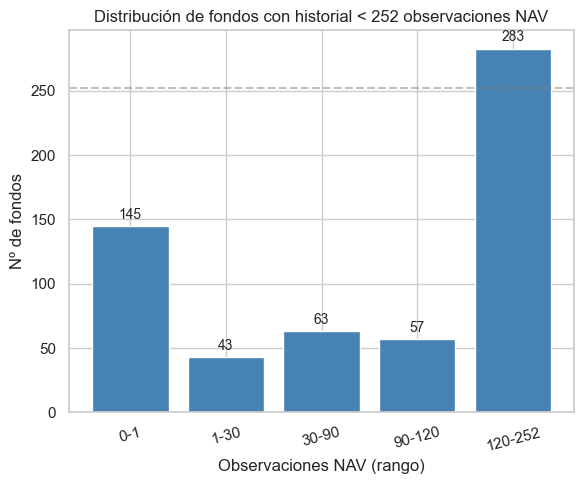

Resumen por rango de observaciones:
bucket
0-1        145
1-30        43
30-90       63
90-120      57
120-252    283

Total fondos < 252 obs: 591


In [ ]:
# Fondos con historial < 252
fondos_lt_252 = coverage_by_fund[coverage_by_fund["obs_nav_no_nulo"] < 252].copy()

# Límites de los intervalos (en obs NAV)
limites = [0, 1, 30, 90, 120, 252]
etiquetas = ["0-1", "1-30", "30-90", "90-120", "120-252"]

fondos_lt_252["bucket"] = pd.cut(
    fondos_lt_252["obs_nav_no_nulo"],
    bins=limites,
    labels=etiquetas,
    include_lowest=True,
)

distribucion = fondos_lt_252["bucket"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(distribucion.index.astype(str), distribucion.values, color="steelblue", edgecolor="white")

ax.set_xlabel("Observaciones NAV (rango)")
ax.set_ylabel("Nº de fondos")
ax.set_title("Distribución de fondos con historial < 252 observaciones NAV")
ax.axhline(y=252, color="gray", linestyle="--", alpha=0.5, label="Umbral 252")
plt.xticks(rotation=15)

# Valores sobre cada barra
for bar in bars:
    h = bar.get_height()
    ax.annotate(f"{int(h)}", xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# Resumen numérico
print("Resumen por rango de observaciones:")
print(distribucion.to_string())
print(f"\nTotal fondos < 252 obs: {fondos_lt_252.shape[0]}")

**Interpretación (3.2)**

- **Esperado sano**: la mayoría de fondos cumple el umbral mínimo de historial. Concretamente, **24.228 fondos** tienen ≥252 observaciones NAV (`flag_historial_min_1y = 1`), frente a **591 fondos** por debajo. La distribución de los 591 con historial insuficiente muestra que **145 fondos (24,5%)** tienen 0–1 observaciones, **86 (14,6%)** entre 1–30, y **283 (47,9%)** entre 120–252 (cercanos al umbral).

- **Señal de riesgo**: existe una cola de fondos con baja completitud o historial muy corto. Los **188 fondos** con menos de 30 observaciones pueden introducir ruido y sesgo en modelos supervisados. Los **145 fondos con 0–1 obs** son especialmente problemáticos (casi sin historial). El gráfico de distribución por rangos (0–1, 1–30, 30–90, 90–120, 120–252) refleja esta heterogeneidad y prioriza dónde concentrar el filtrado en fase 4.

- **Diferencia entre cobertura y longitud**: un fondo puede tener `min_date` antigua pero baja completitud (muchos huecos), por lo que antigüedad no equivale a calidad de historial. Los indicadores `ratio_completitud` y `obs_nav_no_nulo` capturan esto: un fondo con muchos días entre min y max pero pocas obs tendrá ratio bajo y `flag_historial_min_1y = 0`.

- **Implicación para fase 4**: este diagnóstico define umbrales de exclusión o reglas de tratamiento. Se recomienda excluir al menos los fondos con <30 obs NAV (188 fondos); los 283 entre 120–252 pueden evaluarse según el modelo (ya que podrian tener frecuencia semanal). El sistema de alertas de 3.5 usa estos umbrales para priorizar el trabajo de limpieza.

### 3.3 - Frecuencia observada de actualización NAV por fondo

En un panel diario de fondos, la presencia de `NaN` en `nav` no siempre implica mala calidad de dato. Muchas veces refleja la **frecuencia natural de publicación** del fondo (por ejemplo, semanal o mensual).  

Por eso, antes de limpiar o imputar, conviene inferir la frecuencia observada a partir de fechas válidas por fondo.

Este diagnóstico permite separar dos fenómenos distintos:

- **NaN estructural**: esperado por diseño de publicación (fondos no diarios).
- **NaN potencialmente problemático**: huecos anómalos para la frecuencia esperada del fondo.

La clasificación en `daily`, `weekly`, `monthly`, `irregular` (más `insufficient_data`) no corrige nada todavía, pero aporta evidencia para justificar en fases posteriores una posible homogenización temporal (por ejemplo, frecuencia semanal) con menor riesgo de distorsión.

SECCION 3.3 - FRECUENCIA OBSERVADA DE ACTUALIZACION NAV POR FONDO
Heuristica usada:
- insufficient_data: < 8 observaciones validas de NAV
- daily: mediana gap <= 2 y >= 80% gaps <= 3
- weekly: mediana gap [5,9] y >= 60% gaps en [4,10]
- monthly: mediana gap [24,35] y >= 50% gaps en [20,40]
- irregular: resto
--------------------------------------------------------------------------------------------
Distribucion de fondos por categoria de frecuencia observada


,freq_categoria,n_fondos,porcentaje
0,daily,24438,98.464886
1,insufficient_data,162,0.652726
2,irregular,136,0.547967
3,weekly,78,0.314275
4,monthly,5,0.020146


Ejemplos de fondos por categoria (hasta 5 por categoria)


,allfunds_id,freq_categoria,n_obs_nav_validas,median_gap_dias,p90_gap_dias,min_date,max_date
0,187743,daily,2016,1.0,1.0,2016-01-05,2021-07-15
1,215070,daily,2016,1.0,1.0,2016-01-05,2021-07-15
2,70019,daily,2015,1.0,1.0,2016-01-05,2021-07-15
3,175855,daily,2015,1.0,1.0,2016-01-05,2021-07-14
4,220250,daily,2015,1.0,1.0,2016-01-05,2021-07-15
5,54669,insufficient_data,7,132.5,369.5,2018-05-31,2021-04-30
6,175693,insufficient_data,7,1.0,2.0,2017-06-27,2017-07-05
7,255398,insufficient_data,7,1.0,176.0,2020-07-24,2021-07-15
8,295598,insufficient_data,6,1.0,2.2,2021-07-08,2021-07-15
9,317726,insufficient_data,6,1.0,2.2,2021-07-08,2021-07-15


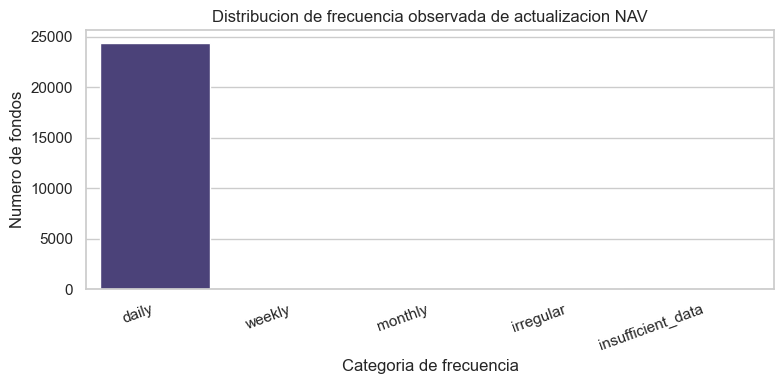

In [11]:
# 3.3 - Frecuencia observada de actualizacion NAV por fondo (solo caracterizacion)
# Restricciones: no remuestrear, no imputar, no limpiar correctivamente.

if "daily_panel" not in globals():
    raise NameError("No existe `daily_panel` en memoria. Ejecuta antes la construccion/carga del panel.")

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

panel = daily_panel

# Seleccion robusta de clave de fondo
if "allfunds_id" in panel.columns:
    fund_col = "allfunds_id"
elif "isin" in panel.columns:
    fund_col = "isin"
else:
    raise KeyError("Se requiere `allfunds_id` o `isin` para analizar frecuencia por fondo.")

# Seleccion robusta de fecha
if "date" in panel.columns:
    date_col = "date"
else:
    dt_candidates = panel.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if not dt_candidates:
        raise KeyError("No se detecto columna temporal. Se esperaba `date` o dtype datetime.")
    date_col = dt_candidates[0]

if "nav" not in panel.columns:
    raise KeyError("Se requiere columna `nav` para inferir frecuencia observada.")

work = panel[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.dropna(subset=[fund_col, date_col])

# Solo fechas con NAV valido
valid_nav = work.loc[work["nav"].notna(), [fund_col, date_col]].copy()
valid_nav = valid_nav.sort_values([fund_col, date_col]).drop_duplicates([fund_col, date_col])


def classify_frequency(gaps_days: pd.Series, min_obs_required: int = 8) -> str:
    """
    Heuristica explicita basada en gaps entre fechas con NAV no nulo:
    - insufficient_data: menos de `min_obs_required` observaciones validas.
    - daily: mediana gap <= 2 dias y >=80% gaps <= 3 dias.
    - weekly: mediana gap entre 5 y 9 dias y >=60% gaps entre 4 y 10 dias.
    - monthly: mediana gap entre 24 y 35 dias y >=50% gaps entre 20 y 40 dias.
    - irregular: resto de casos.
    """
    n_obs = len(gaps_days) + 1
    if n_obs < min_obs_required:
        return "insufficient_data"

    med = float(gaps_days.median())
    p_daily_like = float((gaps_days <= 3).mean()) if len(gaps_days) else 0.0
    p_weekly_like = float(gaps_days.between(4, 10, inclusive="both").mean()) if len(gaps_days) else 0.0
    p_monthly_like = float(gaps_days.between(20, 40, inclusive="both").mean()) if len(gaps_days) else 0.0

    if med <= 2 and p_daily_like >= 0.80:
        return "daily"
    if 5 <= med <= 9 and p_weekly_like >= 0.60:
        return "weekly"
    if 24 <= med <= 35 and p_monthly_like >= 0.50:
        return "monthly"
    return "irregular"


# Calculo de estadisticas de gap por fondo
rows = []
for fund_id, g in valid_nav.groupby(fund_col):
    dates = g[date_col].sort_values()
    gaps = dates.diff().dropna().dt.days
    n_obs = int(len(dates))

    if n_obs <= 1:
        freq_cat = "insufficient_data"
        median_gap = np.nan
        p90_gap = np.nan
    else:
        freq_cat = classify_frequency(gaps)
        median_gap = float(gaps.median())
        p90_gap = float(gaps.quantile(0.90))

    rows.append(
        {
            fund_col: fund_id,
            "n_obs_nav_validas": n_obs,
            "min_date": dates.min() if n_obs else pd.NaT,
            "max_date": dates.max() if n_obs else pd.NaT,
            "median_gap_dias": median_gap,
            "p90_gap_dias": p90_gap,
            "freq_categoria": freq_cat,
        }
    )

freq_by_fund = pd.DataFrame(rows)

# Distribucion por categoria
dist_freq = (
    freq_by_fund["freq_categoria"]
    .value_counts(dropna=False)
    .rename_axis("freq_categoria")
    .reset_index(name="n_fondos")
)
dist_freq["porcentaje"] = dist_freq["n_fondos"] / dist_freq["n_fondos"].sum() * 100

# Ejemplos por categoria (hasta 5 fondos por categoria)
examples_by_category = (
    freq_by_fund
    .sort_values(["freq_categoria", "n_obs_nav_validas"], ascending=[True, False])
    .groupby("freq_categoria", as_index=False)
    .head(5)
    [[fund_col, "freq_categoria", "n_obs_nav_validas", "median_gap_dias", "p90_gap_dias", "min_date", "max_date"]]
    .reset_index(drop=True)
)

print("=" * 92)
print("SECCION 3.3 - FRECUENCIA OBSERVADA DE ACTUALIZACION NAV POR FONDO")
print("=" * 92)
print("Heuristica usada:")
print("- insufficient_data: < 8 observaciones validas de NAV")
print("- daily: mediana gap <= 2 y >= 80% gaps <= 3")
print("- weekly: mediana gap [5,9] y >= 60% gaps en [4,10]")
print("- monthly: mediana gap [24,35] y >= 50% gaps en [20,40]")
print("- irregular: resto")
print("-" * 92)
print("Distribucion de fondos por categoria de frecuencia observada")
display(dist_freq)
print("Ejemplos de fondos por categoria (hasta 5 por categoria)")
display(examples_by_category)

# Grafico simple
plot_order = ["daily", "weekly", "monthly", "irregular", "insufficient_data"]
plot_df = dist_freq.copy()
plot_df["freq_categoria"] = pd.Categorical(plot_df["freq_categoria"], categories=plot_order, ordered=True)
plot_df = plot_df.sort_values("freq_categoria")

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=plot_df, x="freq_categoria", y="n_fondos", hue="freq_categoria", palette="viridis", legend=False)
ax.set_title("Distribucion de frecuencia observada de actualizacion NAV")
ax.set_xlabel("Categoria de frecuencia")
ax.set_ylabel("Numero de fondos")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Objeto util para pipeline posterior
freq_33 = freq_by_fund.copy()

**Interpretación de resultados (3.3)**

- **Dominancia de fondos daily (~98.5%)**: Casi todos los fondos se clasifican como actualización diaria; los NaN no se deben en su mayoría a fondos semanales o mensuales. La alta proporción de nulos global (sección 3.4) responde más a inicio/fin de series, festivos o huecos puntuales que a diseño de publicación.
- **weekly (78) y monthly (5)**: Muy minoritarios; la homogenización a frecuencia semanal tendría impacto limitado en el conjunto del universo.
- **insufficient_data (162)**: Fondos con pocas observaciones válidas; conviene excluirlos o tratarlos aparte en modelado para evitar inferencia poco fiable.
- **irregular (136)**: Patrones de actualización no claramente daily/weekly/monthly; candidatos a revisión manual o reglas específicas en la fase de limpieza.
- **Conclusión**: El panel es principalmente diario por diseño observado; el análisis a frecuencia diaria es razonable. Una homogenización a semanal sería opcional para reducir ruido, no necesaria por tener muchos fondos no diarios.

### 3.4 - Calidad de NAV y anomalías preliminares

Antes de limpiar o modelar, conviene auditar la calidad de `nav` porque esta variable es la base de retornos, features y etiquetas posteriores. Si `nav` contiene huecos, valores no plausibles (`<= 0`) o saltos extremos, el riesgo es propagar ruido a toda la cadena analítica.

En esta subsección diferenciamos **diagnóstico** de **corrección**:

- Medimos nulos globales y por fondo,
- Identificamos casos `nav <= 0`,
- Evaluamos la distribución de NAV,
- Analizamos retornos diarios (agregados) y marcamos extremos con percentiles e IQR globales, sin limpieza correctiva,
- Marcamos extremos con criterios explícitos (percentiles 1%-99% e IQR).

Esto permite anticipar si los problemas son puntuales o sistémicos y preparar reglas de fase 4 con evidencia, evitando decisiones ad hoc.

SECCION 3.4 - CALIDAD DE NAV Y ANOMALIAS PRELIMINARES
Filas evaluadas: 50,134,380
% NAV nulo global: 41.25%
NAV <= 0 global: 0 (0.00%)
Retornos validos analizados: 22,953,912
Umbral extremos percentiles (1%-99%): [-0.025459, 0.023269]
Umbral extremos IQR: [-0.008837, 0.009730]
----------------------------------------------------------------------------------------------
Estadisticos de retornos diarios POR FONDO (muestra: fondos con mas retornos validos)


,allfunds_id,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,n_ret_valid
16024,187743,2013.0,0.000054,0.000992,-0.013127,-0.002458,-0.001045,-0.000126,0.000052,0.000312,0.001147,0.002634,0.006262,2013
17760,215070,2013.0,0.000064,0.001174,-0.014894,-0.002990,-0.001102,-0.000117,0.000051,0.000331,0.001214,0.003217,0.009855,2013
15557,175855,2012.0,0.000009,0.000976,-0.008762,-0.003062,-0.001253,-0.000187,0.000040,0.000187,0.001245,0.002727,0.012690,2012
24613,567070,2012.0,-0.000005,0.000603,-0.012830,-0.001442,-0.000546,-0.000096,0.000027,0.000095,0.000536,0.001229,0.004802,2012
24612,567026,2012.0,0.000340,0.009828,-0.113623,-0.030241,-0.013229,-0.001577,-0.000054,0.003473,0.013085,0.024370,0.096893,2012
24616,590030,2012.0,0.000148,0.007954,-0.104513,-0.022400,-0.011827,-0.001746,-0.000059,0.003020,0.011395,0.020664,0.040840,2012
9349,82293,2011.0,-0.000020,0.000053,-0.000640,-0.000196,-0.000111,-0.000031,-0.000021,0.000007,0.000047,0.000085,0.000673,2011
8671,76298,2011.0,0.000062,0.002639,-0.034681,-0.007851,-0.002955,-0.000367,0.000013,0.000722,0.003078,0.007204,0.022076,2011
24536,542016,2011.0,0.000090,0.008697,-0.113660,-0.025235,-0.012617,-0.001848,-0.000024,0.002969,0.012294,0.023328,0.076924,2011
18065,220250,2011.0,0.000073,0.001708,-0.025936,-0.004505,-0.001657,-0.000107,0.000072,0.000407,0.001729,0.004326,0.015047,2011


Top 50 fondos por incidencia de anomalias (score combinado diagnostico)


,allfunds_id,n_rows,n_nav_null,n_nav_nonpos,pct_nav_null,pct_nav_nonpos,n_ret_valid,n_extremos_pct,n_extremos_iqr,pct_extremos_pct,pct_extremos_iqr,anom_score
8920,79184,2020,1973,0,0.976733,0.0,36,10,24,0.277778,0.666667,0.608523
23619,291534,2020,1920,0,0.950495,0.0,77,17,47,0.220779,0.610390,0.576829
22244,276575,2020,1842,0,0.911881,0.0,132,22,81,0.166667,0.613636,0.564613
22249,276671,2020,1842,0,0.911881,0.0,132,26,80,0.196970,0.606061,0.561583
22250,276689,2020,1842,0,0.911881,0.0,132,26,80,0.196970,0.606061,0.561583
22247,276641,2020,1842,0,0.911881,0.0,132,26,80,0.196970,0.606061,0.561583
22248,276646,2020,1842,0,0.911881,0.0,132,26,80,0.196970,0.606061,0.561583
20023,250317,2020,1704,0,0.843564,0.0,244,59,160,0.241803,0.655738,0.557543
15054,167213,2020,1797,0,0.889604,0.0,220,88,133,0.400000,0.604545,0.553180
15412,172939,2020,2005,0,0.992574,0.0,10,1,5,0.100000,0.500000,0.547401


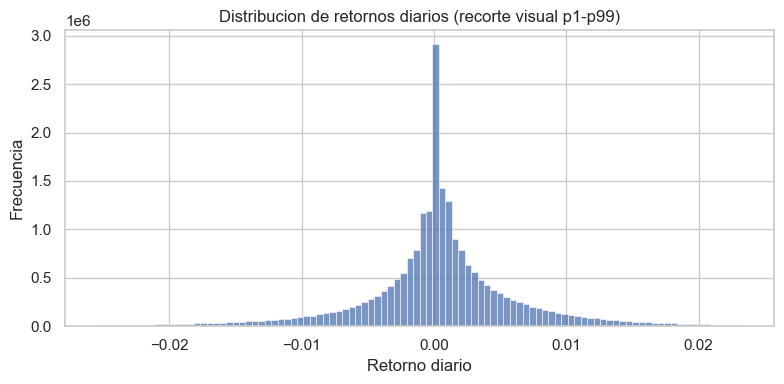

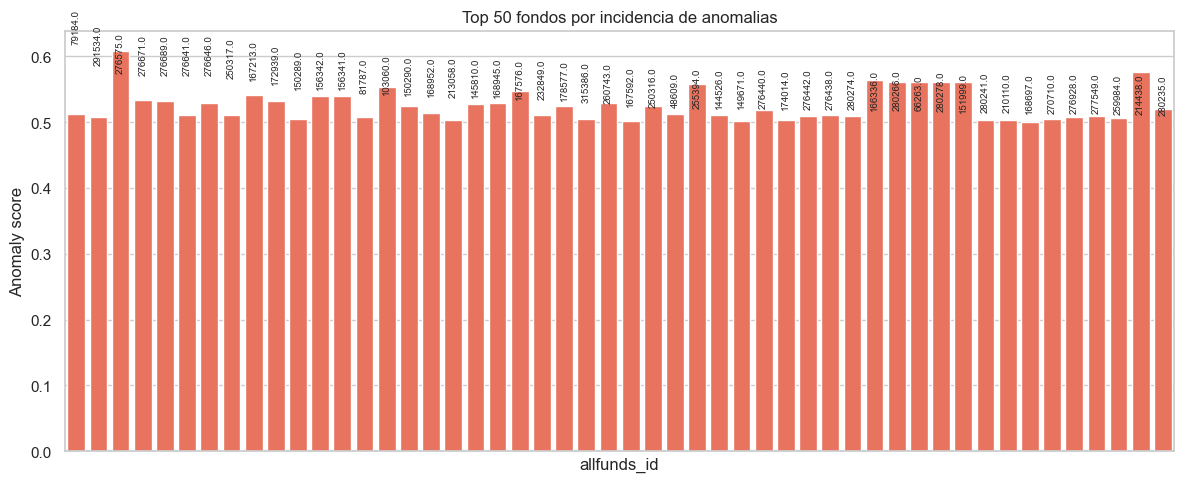

In [25]:
# 3.4 - Calidad de NAV y anomalías preliminares (EDA diagnóstico)
# Restricciones: no corregir, no imputar, no eliminar registros.
# Sin estadísticos de NAV; con estadísticos de retornos diarios por fondo.

if "daily_panel" not in globals():
    raise NameError("No existe `daily_panel` en memoria. Ejecuta antes la construccion/carga del panel.")

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

panel = daily_panel

if "nav" not in panel.columns:
    raise KeyError("Se requiere columna `nav` para el diagnostico 3.4.")

def _pick_fund_col(df: pd.DataFrame) -> str:
    if "allfunds_id" in df.columns:
        return "allfunds_id"
    if "isin" in df.columns:
        return "isin"
    raise KeyError("Se requiere `allfunds_id` o `isin` para analisis por fondo.")

def _pick_date_col(df: pd.DataFrame) -> str:
    if "date" in df.columns:
        return "date"
    dt = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if not dt:
        raise KeyError("No se detecto columna temporal. Se esperaba `date` o dtype datetime.")
    return dt[0]

fund_col = _pick_fund_col(panel)
date_col = _pick_date_col(panel)

work = panel[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.dropna(subset=[fund_col, date_col])

# 1) Nulos NAV global y por fondo
n_total = len(work)
nav_null_global_pct = float(work["nav"].isna().mean() * 100)

nav_quality_by_fund = (
    work.groupby(fund_col)
    .agg(
        n_rows=("nav", "size"),
        n_nav_null=("nav", lambda s: int(s.isna().sum())),
        n_nav_nonpos=("nav", lambda s: int((s <= 0).sum())),
    )
    .reset_index()
)
nav_quality_by_fund["pct_nav_null"] = nav_quality_by_fund["n_nav_null"] / nav_quality_by_fund["n_rows"]
nav_quality_by_fund["pct_nav_nonpos"] = nav_quality_by_fund["n_nav_nonpos"] / nav_quality_by_fund["n_rows"]

# 2) Casos nav <= 0 global
n_nav_nonpos_global = int((work["nav"] <= 0).sum())
pct_nav_nonpos_global = float((work["nav"] <= 0).mean() * 100)

# 3) Retornos diarios por fondo (sin limpieza correctiva)
ret_df = work[[fund_col, date_col, "nav"]].copy().sort_values([fund_col, date_col])
ret_df["ret_1d"] = ret_df.groupby(fund_col)["nav"].pct_change(fill_method=None)
ret_df["ret_1d"] = ret_df["ret_1d"].replace([np.inf, -np.inf], np.nan)

ret_series = ret_df["ret_1d"].dropna()

# 4) Estadísticos de retornos diarios POR FONDO
ret_stats_by_fund = (
    ret_df.groupby(fund_col)["ret_1d"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)

# 5) Extremos diagnósticos (criterio explícito)
q_low, q_high = ret_series.quantile([0.01, 0.99]) if len(ret_series) else (np.nan, np.nan)
ret_df["flag_extremo_pct"] = ret_df["ret_1d"].lt(q_low) | ret_df["ret_1d"].gt(q_high)

q1, q3 = ret_series.quantile([0.25, 0.75]) if len(ret_series) else (np.nan, np.nan)
iqr = q3 - q1 if pd.notna(q1) and pd.notna(q3) else np.nan
iqr_low = q1 - 1.5 * iqr if pd.notna(iqr) else np.nan
iqr_high = q3 + 1.5 * iqr if pd.notna(iqr) else np.nan
ret_df["flag_extremo_iqr"] = ret_df["ret_1d"].lt(iqr_low) | ret_df["ret_1d"].gt(iqr_high)

ret_anom_by_fund = (
    ret_df.groupby(fund_col)
    .agg(
        n_ret_valid=("ret_1d", lambda s: int(s.notna().sum())),
        n_extremos_pct=("flag_extremo_pct", lambda s: int(s.fillna(False).sum())),
        n_extremos_iqr=("flag_extremo_iqr", lambda s: int(s.fillna(False).sum())),
    )
    .reset_index()
)
ret_anom_by_fund["pct_extremos_pct"] = np.where(
    ret_anom_by_fund["n_ret_valid"] > 0,
    ret_anom_by_fund["n_extremos_pct"] / ret_anom_by_fund["n_ret_valid"],
    0.0,
)
ret_anom_by_fund["pct_extremos_iqr"] = np.where(
    ret_anom_by_fund["n_ret_valid"] > 0,
    ret_anom_by_fund["n_extremos_iqr"] / ret_anom_by_fund["n_ret_valid"],
    0.0,
)

# 6) Top 50 fondos por incidencia de anomalías
anom_by_fund = nav_quality_by_fund.merge(ret_anom_by_fund, on=fund_col, how="left")
for c in ["n_ret_valid", "n_extremos_pct", "n_extremos_iqr", "pct_extremos_pct", "pct_extremos_iqr"]:
    anom_by_fund[c] = anom_by_fund[c].fillna(0)

anom_by_fund["anom_score"] = (
    0.35 * anom_by_fund["pct_nav_null"]
    + 0.25 * anom_by_fund["pct_nav_nonpos"]
    + 0.40 * anom_by_fund["pct_extremos_iqr"]
)

top50_anomalias = anom_by_fund.sort_values("anom_score", ascending=False).head(50)

# --- Salida ---
print("=" * 94)
print("SECCION 3.4 - CALIDAD DE NAV Y ANOMALIAS PRELIMINARES")
print("=" * 94)
print(f"Filas evaluadas: {n_total:,}")
print(f"% NAV nulo global: {nav_null_global_pct:.2f}%")
print(f"NAV <= 0 global: {n_nav_nonpos_global:,} ({pct_nav_nonpos_global:.2f}%)")
print(f"Retornos validos analizados: {len(ret_series):,}")
print(f"Umbral extremos percentiles (1%-99%): [{q_low:.6f}, {q_high:.6f}]")
print(f"Umbral extremos IQR: [{iqr_low:.6f}, {iqr_high:.6f}]")
print("-" * 94)
print("Estadisticos de retornos diarios POR FONDO (muestra: fondos con mas retornos validos)")
# Ordenar por count y mostrar muestra
ret_stats_orden = ret_stats_by_fund.merge(
    ret_anom_by_fund[[fund_col, "n_ret_valid"]], on=fund_col
).sort_values("n_ret_valid", ascending=False)
display(ret_stats_orden.head(20))
print("Top 50 fondos por incidencia de anomalias (score combinado diagnostico)")
display(top50_anomalias)

# Gráficos (sin histograma de NAV)
r_lo, r_hi = ret_series.quantile([0.01, 0.99]) if len(ret_series) else (np.nan, np.nan)
ret_plot = ret_series[(ret_series >= r_lo) & (ret_series <= r_hi)] if pd.notna(r_lo) else ret_series

plt.figure(figsize=(8, 4))
_ = sns.histplot(ret_plot, bins=100, kde=False)
plt.title("Distribucion de retornos diarios (recorte visual p1-p99)")
plt.xlabel("Retorno diario")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=top50_anomalias, x=fund_col, y="anom_score", color="tomato")
plt.title("Top 50 fondos por incidencia de anomalias")
plt.xlabel(fund_col)
plt.ylabel("Anomaly score")

# Fund ID sobre cada barra
for i, (_, row) in enumerate(top50_anomalias.iterrows()):
    ax.text(i, row["anom_score"] + 0.01, str(row[fund_col]), 
            ha="center", va="bottom", rotation=90, fontsize=7)

plt.xticks([], [])
plt.tight_layout()
plt.show()

nav_quality_34 = nav_quality_by_fund.copy()
ret_quality_34 = ret_anom_by_fund.copy()
anom_34 = anom_by_fund.copy()
ret_stats_by_fund_34 = ret_stats_by_fund.copy()



**Interpretación de resultados (3.4)**

- **NAV nulo (41.25%)**: Proporción esperable en un panel diario con fondos de liquidación semanal/mensual; no implica error por sí mismo.
- **NAV ≤ 0 (0%)**: No hay NAV negativos ni cero; sin indicios de corrupción básica en el dato.
- **Retornos extremos**: Los umbrales 1%-99% e IQR marcan rangos razonables. Fondos con std muy alto (p. ej. 24612, 24616, 21968: std ~0.008–0.01) muestran mayor volatilidad o posibles discontinuidades; merecen revisión. (Podria ser fondos de frecuencia semanal o mensual, que al dar el dato no es comparable con los retornos diarios, creando asi un falso retorno extremo)
- **Top 50 anomalías**: Se combinan alto % de NAV nulo (80–99%) con alta proporción de retornos extremos (pct_extremos_pct y pct_extremos_iqr elevados). Son candidatos naturales a reglas de calidad más estrictas en la fase de preprocesado.
- **Fondos con patrón similar** (22xxx, 27xxx): Grupos de fondos con métricas muy parecidas, posiblemente misma gestora o familia; puede priorizarse un tratamiento conjunto.
- **Enfoque**: Este diagnóstico prioriza qué fondos tratar en fases posteriores; no implica borrar ni corregir datos todavía.

### 3.5 - Sistema de alertas EDA y resumen ejecutivo

El cierre de EDA traduce hallazgos técnicos en **señales accionables** para la fase 4. Este bloque consolida evidencias de secciones previas en una vista única por fondo. El objetivo no es excluir automáticamente, sino responder con datos a preguntas de gobierno del dato:

- ¿Qué fondos concentran más problemas estructurales?
- ¿Qué tipo de riesgo domina (cobertura, NAV, frecuencia)?
- ¿Qué reglas de fase 4 tienen mayor impacto potencial?

---

**Interpretación punto por punto**

**1) 3.1 - Vista general de calidad**  
Diagnóstico inicial: validación de estructura, cobertura e integridad del panel diario sin correcciones. Base para entender el alcance del universo y la naturaleza de los datos.

**2) 3.2 - Cobertura temporal y completitud**  
- 24,228 fondos (97.6%) cumplen historial mínimo ≥252 obs; 591 (2.4%) no.  
- Cola de fondos con baja `ratio_completitud`: antigüedad no implica calidad (muchos huecos).  
- Implicación: definir umbrales de exclusión o tratamiento de faltantes por fondo.

**3) 3.3 - Frecuencia observada**  
- ~98.5% clasificados como *daily*; weekly (78) y monthly (5) son minoritarios.  
- Los NaN no se explican mayormente por fondos no diarios; más bien por inicio/fin de series, festivos o huecos puntuales.  
- *insufficient_data* (162) e *irregular* (136): candidatos a reglas específicas o exclusión.

**4) 3.4 - Calidad de NAV y anomalías**  
- 41.25% NAV nulo global; 0% NAV ≤0 (sin corrupción aparente).  
- Top 50 anomalías: alto % de null (80–99%) y alta incidencia de retornos extremos.  
- Fondos con std muy alto (p. ej. 24612, 24616): revisar posibles discontinuidades o volatilidad real.  
- Clusters de fondos similares (22xxx, 27xxx): posible misma gestora/familia.

**5) 3.5 - Sistema de alertas (síntesis)**  
Con umbrales `cobertura_baja<0.60`, `historial<252`, `nav_null_alto>0.50`:  
- **Riesgo dominante**: cobertura_baja (7,399 fondos, 29.8%).  
- **Segundo riesgo**: nav_null_alto (5,835 fondos, 23.5%).  
- historial_lt_1y: 591 (2.4%); freq_irregular: 136 (0.55%).

**Acciones priorizadas para fase 4**  
1. Definir umbral operativo de cobertura mínima por fondo.  
2. Regla para fondos con <252 observaciones válidas.  
3. Tratamiento diferenciado para fondos con alto % de null y/o alta incidencia de extremos.

En términos prácticos, este sistema actúa como **puente directo a fase 4**: prioriza, documenta y justifica decisiones antes de corregir.

In [ ]:
if "daily_panel" not in globals():
    raise NameError("No existe `daily_panel` en memoria. Ejecuta antes la construccion/carga del panel.")

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

panel = daily_panel

# --- utilidades de esquema ---
def _pick_fund_col(df: pd.DataFrame) -> str:
    if "allfunds_id" in df.columns:
        return "allfunds_id"
    if "isin" in df.columns:
        return "isin"
    raise KeyError("Se requiere `allfunds_id` o `isin` para construir alertas por fondo.")


def _pick_date_col(df: pd.DataFrame) -> str:
    if "date" in df.columns:
        return "date"
    dt = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if not dt:
        raise KeyError("No se detecto columna temporal. Se esperaba `date` o dtype datetime.")
    return dt[0]


fund_col = _pick_fund_col(panel)
date_col = _pick_date_col(panel)

work = panel[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.dropna(subset=[fund_col, date_col])

# --- (A) Cobertura / historial (3.2) ---
coverage_tbl = (
    work.groupby(fund_col)
    .agg(
        min_date=(date_col, "min"),
        max_date=(date_col, "max"),
        obs_nav_no_nulo=("nav", lambda s: int(s.notna().sum())),
    )
    .reset_index()
)
coverage_tbl["dias_calendario"] = ((coverage_tbl["max_date"] - coverage_tbl["min_date"]).dt.days + 1).clip(lower=1)
coverage_tbl["ratio_completitud"] = coverage_tbl["obs_nav_no_nulo"] / coverage_tbl["dias_calendario"]

# --- (B) Calidad NAV (3.4) ---
nav_tbl = (
    work.groupby(fund_col)
    .agg(
        n_rows=("nav", "size"),
        n_nav_null=("nav", lambda s: int(s.isna().sum())),
        n_nav_nonpos=("nav", lambda s: int((s <= 0).sum())),
    )
    .reset_index()
)
nav_tbl["pct_nav_null"] = nav_tbl["n_nav_null"] / nav_tbl["n_rows"]
nav_tbl["has_nav_nonpos"] = (nav_tbl["n_nav_nonpos"] > 0).astype(int)

# --- (C) Frecuencia (3.3) ---
valid_nav = work.loc[work["nav"].notna(), [fund_col, date_col]].copy()
valid_nav = valid_nav.sort_values([fund_col, date_col]).drop_duplicates([fund_col, date_col])


def _classify_frequency(gaps_days: pd.Series, min_obs_required: int = 8) -> str:
    n_obs = len(gaps_days) + 1
    if n_obs < min_obs_required:
        return "insufficient_data"

    med = float(gaps_days.median())
    p_daily_like = float((gaps_days <= 3).mean()) if len(gaps_days) else 0.0
    p_weekly_like = float(gaps_days.between(4, 10, inclusive="both").mean()) if len(gaps_days) else 0.0
    p_monthly_like = float(gaps_days.between(20, 40, inclusive="both").mean()) if len(gaps_days) else 0.0

    if med <= 2 and p_daily_like >= 0.80:
        return "daily"
    if 5 <= med <= 9 and p_weekly_like >= 0.60:
        return "weekly"
    if 24 <= med <= 35 and p_monthly_like >= 0.50:
        return "monthly"
    return "irregular"


freq_rows = []
for fid, g in valid_nav.groupby(fund_col):
    dates = g[date_col].sort_values()
    gaps = dates.diff().dropna().dt.days
    freq_rows.append({fund_col: fid, "freq_categoria": _classify_frequency(gaps) if len(dates) > 1 else "insufficient_data"})

freq_tbl = pd.DataFrame(freq_rows)

# --- (D) Consolidado y flags ---
alerts = coverage_tbl.merge(nav_tbl[[fund_col, "pct_nav_null", "has_nav_nonpos"]], on=fund_col, how="left")
alerts = alerts.merge(freq_tbl, on=fund_col, how="left")
alerts["freq_categoria"] = alerts["freq_categoria"].fillna("insufficient_data")

# Umbrales preliminares EDA (ajustables en fase 4)
TH_COBERTURA_BAJA = 0.60
TH_OBS_MIN_1Y = 252
TH_NAV_NULL_ALTO = 0.50

alerts["flag_cobertura_baja"] = (alerts["ratio_completitud"] < TH_COBERTURA_BAJA).astype(int)
alerts["flag_historial_lt_1y"] = (alerts["obs_nav_no_nulo"] < TH_OBS_MIN_1Y).astype(int)
alerts["flag_nav_null_alto"] = (alerts["pct_nav_null"] > TH_NAV_NULL_ALTO).astype(int)
alerts["flag_nav_nonpos"] = alerts["has_nav_nonpos"].astype(int)
alerts["flag_freq_irregular"] = (alerts["freq_categoria"] == "irregular").astype(int)

flag_cols = [
    "flag_cobertura_baja",
    "flag_historial_lt_1y",
    "flag_nav_null_alto",
    "flag_nav_nonpos",
    "flag_freq_irregular",
]

alerts["alert_score"] = alerts[flag_cols].sum(axis=1)

# Ranking de fondos mas problematicos
ranking_top50 = (
    alerts.sort_values(
        ["alert_score", "flag_nav_nonpos", "flag_nav_null_alto", "flag_cobertura_baja", "ratio_completitud"],
        ascending=[False, False, False, False, True],
    )
    .head(50)
)

# Resumen de alertas
resumen_alertas = pd.DataFrame(
    {
        "alerta": [
            "cobertura_baja",
            "historial_lt_1y",
            "nav_null_alto",
            "nav_nonpos",
            "freq_irregular",
        ],
        "n_fondos": [
            int(alerts["flag_cobertura_baja"].sum()),
            int(alerts["flag_historial_lt_1y"].sum()),
            int(alerts["flag_nav_null_alto"].sum()),
            int(alerts["flag_nav_nonpos"].sum()),
            int(alerts["flag_freq_irregular"].sum()),
        ],
    }
)
resumen_alertas["porcentaje_fondos"] = 100 * resumen_alertas["n_fondos"] / len(alerts)

# --- salida principal ---
print("=" * 96)
print("SECCION 3.5 - SISTEMA DE ALERTAS EDA Y RESUMEN EJECUTIVO")
print("=" * 96)
print(f"Fondos evaluados: {len(alerts):,}")
print(f"Umbrales: cobertura_baja<{TH_COBERTURA_BAJA:.2f}, historial<{TH_OBS_MIN_1Y}, nav_null_alto>{TH_NAV_NULL_ALTO:.2f}")
print("-" * 96)
print("Tabla consolidada de flags por fondo")
display(alerts[[fund_col, "ratio_completitud", "obs_nav_no_nulo", "pct_nav_null", "has_nav_nonpos", "freq_categoria"] + flag_cols + ["alert_score"]])
print("Top 50 fondos mas problematicos")
display(ranking_top50[[fund_col, "alert_score", "ratio_completitud", "obs_nav_no_nulo", "pct_nav_null", "has_nav_nonpos", "freq_categoria"] + flag_cols])
print("Resumen de fondos por tipo de alerta")
display(resumen_alertas.sort_values("n_fondos", ascending=False))

# --- conclusion automatica ---
dom = resumen_alertas.sort_values("n_fondos", ascending=False).reset_index(drop=True)
main_risk = dom.loc[0, "alerta"] if len(dom) else "sin_alertas"
second_risk = dom.loc[1, "alerta"] if len(dom) > 1 else "n/a"

print("\nCONCLUSION AUTOMATICA (PUENTE A FASE 4)")
print(f"- Riesgo dominante: {main_risk}")
print(f"- Segundo riesgo: {second_risk}")
print("- Decisiones recomendadas para fase 4:")
print("  1) Definir umbral operativo de cobertura minima por fondo.")
print("  2) Establecer regla para fondos con <252 observaciones validas.")
print("  3) Tratar explicitamente NAV <= 0 (invalidos o casos especiales).")
print("  4) Ajustar estrategia por frecuencia irregular antes de features/modelado.")
print("  5) Validar si los umbrales preliminares deben endurecerse o relajarse.")

# Objetos puente para fase 4
alerts_35 = alerts.copy()
alerts_summary_35 = resumen_alertas.copy()

SECCION 3.5 - SISTEMA DE ALERTAS EDA Y RESUMEN EJECUTIVO
Fondos evaluados: 24,819
Umbrales: cobertura_baja<0.60, historial<252, nav_null_alto>0.50
------------------------------------------------------------------------------------------------
Tabla consolidada de flags por fondo


,allfunds_id,ratio_completitud,obs_nav_no_nulo,pct_nav_null,has_nav_nonpos,freq_categoria,flag_cobertura_baja,flag_historial_lt_1y,flag_nav_null_alto,flag_nav_nonpos,flag_freq_irregular,alert_score
0,8,0.686634,1387,0.313366,0,daily,0,0,0,0,0,0
1,9,0.686634,1387,0.313366,0,daily,0,0,0,0,0,0
2,12,0.686139,1386,0.313861,0,daily,0,0,0,0,0,0
3,19,0.705446,1425,0.294554,0,daily,0,0,0,0,0,0
4,20,0.705446,1425,0.294554,0,daily,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
24814,900065,0.672277,1358,0.327723,0,daily,0,0,0,0,0,0
24815,900109,0.164356,332,0.835644,0,daily,1,0,1,0,0,2
24816,901209,0.698020,1410,0.301980,0,daily,0,0,0,0,0,0
24817,901433,0.164851,333,0.835149,0,daily,1,0,1,0,0,2


Top 50 fondos mas problematicos


,allfunds_id,alert_score,ratio_completitud,obs_nav_no_nulo,pct_nav_null,has_nav_nonpos,freq_categoria,flag_cobertura_baja,flag_historial_lt_1y,flag_nav_null_alto,flag_nav_nonpos,flag_freq_irregular
5001,41538,4,0.011881,24,0.988119,0,irregular,1,1,1,0,1
19096,240116,4,0.024257,49,0.975743,0,irregular,1,1,1,0,1
16412,192033,4,0.037624,76,0.962376,0,irregular,1,1,1,0,1
4256,32847,4,0.047525,96,0.952475,0,irregular,1,1,1,0,1
4258,32849,4,0.051485,104,0.948515,0,irregular,1,1,1,0,1
4257,32848,4,0.051980,105,0.948020,0,irregular,1,1,1,0,1
3456,25755,4,0.053960,109,0.946040,0,irregular,1,1,1,0,1
20890,261870,4,0.058911,119,0.941089,0,irregular,1,1,1,0,1
3574,26723,4,0.064851,131,0.935149,0,irregular,1,1,1,0,1
3576,26731,4,0.064851,131,0.935149,0,irregular,1,1,1,0,1


Resumen de fondos por tipo de alerta


,alerta,n_fondos,porcentaje_fondos
0,cobertura_baja,7399,29.811838
2,nav_null_alto,5835,23.510214
1,historial_lt_1y,591,2.381240
4,freq_irregular,136,0.547967
3,nav_nonpos,0,0.000000



CONCLUSION AUTOMATICA (PUENTE A FASE 4)
- Riesgo dominante: cobertura_baja
- Segundo riesgo: nav_null_alto
- Decisiones recomendadas para fase 4:
  1) Definir umbral operativo de cobertura minima por fondo.
  2) Establecer regla para fondos con <252 observaciones validas.
  3) Tratar explicitamente NAV <= 0 (invalidos o casos especiales).
  4) Ajustar estrategia por frecuencia irregular antes de features/modelado.
  5) Validar si los umbrales preliminares deben endurecerse o relajarse.


## 4) Limpieza de datos (reglas explícitas)

- Eliminar fondos con demasiados faltantes (definir umbral, por ejemplo 30%).
- Aplicar imputación simple si procede (`ffill`/`bfill`) y justificar.
- Eliminar o tratar valores no positivos antes de calcular log-retornos.
- Tratar outliers extremos solo si están distorsionando resultados.

**Qué justificar:**
- por qué ese umbral de faltantes;
- por qué ese método de imputación;
- por qué se aplica/no se aplica tratamiento de outliers.

In [ ]:
# TODO: Definir y aplicar reglas de limpieza
# TODO: Guardar tablas resumen antes/después de limpiar

## 5. Feature engineering

En este bloque se transformarán NAVs y factores en variables listas para modelado supervisado.
Se buscará un conjunto de features simple, interpretable y temporalmente correcto.

**Decisiones a justificar**
- Definición de retornos y transformaciones aplicadas.
- Variables predictoras elegidas (actuales y/o rezagadas).
- Definición final de `X` y `y`.

**Entregable de la sección:** matriz de features y variable objetivo preparadas para train/test.

In [ ]:
# TODO: Construir features (retornos, rezagos, variables seleccionadas)
# TODO: Definir variable objetivo para supervisado

## 6. Modelado supervisado

Aquí se entrenarán modelos supervisados simples para evaluar la señal predictiva de las features.
La prioridad será comparar de forma clara y con supuestos controlados.

**Decisiones a justificar**
- Modelo principal seleccionado y por qué.
- Configuración mínima de entrenamiento.
- Cómo se evita complejidad innecesaria.

**Entregable de la sección:** modelo entrenado y predicciones sobre el conjunto de test.

In [ ]:
# TODO: Crear split temporal train/test sin shuffle
# TODO: Entrenar modelo supervisado base y generar predicciones

## 7. Evaluación y visualización

Esta sección medirá el rendimiento del modelo con métricas adecuadas al objetivo elegido.
También se incluirán visualizaciones simples para interpretar los resultados.

**Decisiones a justificar**
- Métricas principales seleccionadas.
- Qué gráficos se usarán para interpretar errores/aciertos.
- Cómo se comparará el resultado con una referencia básica.

**Entregable de la sección:** tabla de métricas y gráficos de evaluación del modelo.

In [ ]:
# TODO: Calcular métricas de evaluación según el tipo de objetivo
# TODO: Crear gráficos simples de resultados (real vs predicho o matriz de confusión)

## 8. Conclusiones y limitaciones

Finalmente, se resumirán hallazgos clave, limitaciones metodológicas y riesgos del enfoque.
El objetivo es cerrar con una interpretación honesta y accionable.

**Decisiones a justificar**
- Qué hipótesis quedó mejor respaldada.
- Qué límites tienen datos y modelo.
- Qué mejoras serían prioritarias en una siguiente iteración.

**Entregable de la sección:** conclusión ejecutiva y lista de limitaciones/siguientes pasos.

In [ ]:
# TODO: Redactar conclusiones finales basadas en resultados
# TODO: Documentar limitaciones y próximos pasos

## Checklist de ejecución

- [ ] 1. Objetivo y tesis financiera
- [ ] 2. Carga y alineación temporal de datos
- [ ] 3. EDA (exploración de calidad)
- [ ] 4. Limpieza y preprocesado
- [ ] 5. Feature engineering
- [ ] 6. Modelado supervisado
- [ ] 7. Evaluación y visualización
- [ ] 8. Conclusiones y limitaciones

## Notas de reproducibilidad

- Trabajar siempre con rutas relativas del proyecto.
- Evitar data leakage en cualquier transformación.
- Usar split temporal (sin `shuffle`) para train/test.
- Comentar celdas con claridad para trazabilidad académica.